

This notebook extends the baseline modelling work from the project's first file that i have crea Four new models are developed here, each designed to address a distinct limitation identified in earlier results:


Model 1 — ARIMAX  Rigorous time-series baseline with exogenous market variables; replaces the failed AR(7) from earlier work.
Model 2 — LightGBM Quantile Regression Produces probabilistic price intervals rather than single-point forecasts; novel contribution for NFT research.
Model 3 — Tuned Random Forest (Full Feature Set) Applies all spatial, temporal, and market features together; tests whether full feature engineering closes the gap to gradient boosting |
Model 4 — Hybrid LightGBM + SARIMA Residual Correction Decomposes prediction error into structural (ML) and temporal (time-series) components; directly operationalises the thesis that NFT markets are conditionally efficient


In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:

!pip install lightgbm xgboost catboost statsmodels pmdarima -q

In [3]:
import pandas as pd
import numpy as np
import ast
import re
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


Data Loading and Preprocessing



In [4]:

file_path = "/content/drive/MyDrive/decentraland_dataset.csv"
df = pd.read_csv(file_path)

print(f"Raw dataset shape: {df.shape}")
df.head()

Raw dataset shape: (2000, 15)


,Unnamed: 0,contract address,Token_id,sales_price,timestamp,owner_id,bids_count,sales_count,parcels_list,parcels_count,status (label),"adjacency [road, district, plaza]",coordination-est,mana_price,land_price
0,0,0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d,7145929705339707732730866756067132440644,6549000000000000000000,1642942635000,0xda3374ebd805b3d2aa6ee2bc5fcb6d9cc00667e3,3,3,"['21,68']",1,parcel,"[[8, 3, 0]]","[21.0, 68.0]",2.119167,1.387843e+22
1,1,0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d,1157920892373161954235709850086879078474851844...,5387000000000000000000,1643751407000,0x862364e32c4a03fc84c612040657e94927fc3e81,0,1,"['-17,40']",1,parcel,"[[1, 0, 0]]","[-17.0, 40.0]",2.697335,1.453054e+22
2,2,0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d,1157920892373161954235709850086879078277488071...,5299000000000000000000,1642752884000,0x8c593534cc44d3cbb8bde927597611d30f56792b,0,1,"['-76,-44']",1,parcel,"[[5, 0, 7]]","[-76.0, -44.0]",2.636088,1.396863e+22
3,3,0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d,1157920892373161954235709850086879078393184076...,8887000000000000000000,1643885971000,0xe6dcf90f6486978ea42bb68f69653111875105de,0,2,"['-136,-37', '-41,90', '-41,89', '-37,89']",4,road,"[[0, 0, 0], [3, 5, 0], [3, 5, 0], [3, 5, 0]]","[-63.75, 57.75]",2.559175,2.274339e+22
4,4,0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d,11569600475311907757754736652680119189479,6800000000000000000000,1644600068000,0x959e104e1a4db6317fa58f8295f586e1a978c297,3,3,[],0,NaN,[],[0],2.934938,1.995758e+22


In [5]:

df = df.drop(columns=["Unnamed: 0"], errors="ignore")


df["sales_price"] = pd.to_numeric(df["sales_price"], errors="coerce")
df["sales_price_eth"] = df["sales_price"] / 1e18
df["log_sales_price_eth"] = np.log1p(df["sales_price_eth"])

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", errors="coerce")

df["status (label)"] = df["status (label)"].fillna("unknown")
df = df.dropna(subset=["sales_price", "timestamp"])
df = df[(df["sales_price_eth"] > 0) & (df["parcels_count"] > 0)].reset_index(drop=True)

print(f"Clean dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")

Clean dataset shape: (1860, 16)
Date range: 2021-12-21 to 2022-03-03


In [6]:

df["year"]      = df["timestamp"].dt.year
df["month"]     = df["timestamp"].dt.month
df["quarter"]   = df["timestamp"].dt.quarter
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
df["week_number"] = df["timestamp"].dt.isocalendar().week.astype(int)


def parse_adjacency(val):
    try:
        arr = ast.literal_eval(str(val))
        road     = sum(x[0] for x in arr)
        district = sum(x[1] for x in arr)
        plaza    = sum(x[2] for x in arr)
        return pd.Series([road, district, plaza, len(arr)])
    except:
        return pd.Series([0, 0, 0, 0])

df[["road_adj", "district_adj", "plaza_adj", "adjacency_count"]] = (
    df["adjacency [road, district, plaza]"].apply(parse_adjacency)
)


def parse_coords(val):
    nums = re.findall(r"-?\d+\.?\d*", str(val))
    if len(nums) >= 2:
        return pd.Series([float(nums[0]), float(nums[1])])
    return pd.Series([np.nan, np.nan])

df[["coord_x", "coord_y"]] = df["coordination-est"].apply(parse_coords)
df["distance_from_center"] = np.sqrt(df["coord_x"]**2 + df["coord_y"]**2)
df["manhattan_distance"]   = df["coord_x"].abs() + df["coord_y"].abs()


status_dummies = pd.get_dummies(df["status (label)"], prefix="status", drop_first=False, dtype=int)
df = pd.concat([df, status_dummies], axis=1)

df = df.sort_values("timestamp").reset_index(drop=True)

print("Feature engineering complete.")
print(f"Dataset shape: {df.shape}")

Feature engineering complete.
Dataset shape: (1860, 33)


In [7]:
# --- Lag and rolling market-memory features ---
# These capture recent market conditions at the daily level and are
# joined back to individual transactions. All lags use strictly past
# data to prevent leakage.

df["date"] = df["timestamp"].dt.date

daily_market = (
    df.groupby("date")["sales_price_eth"]
    .mean()
    .reset_index()
    .rename(columns={"sales_price_eth": "daily_avg_price_eth"})
)

# Lags (past-day prices)
for lag in [1, 3, 7]:
    daily_market[f"lag_{lag}d"] = daily_market["daily_avg_price_eth"].shift(lag)

# Rolling statistics (shifted by 1 to avoid lookahead)
for window in [3, 7]:
    daily_market[f"roll_{window}d_avg"] = daily_market["daily_avg_price_eth"].shift(1).rolling(window).mean()
    daily_market[f"roll_{window}d_std"] = daily_market["daily_avg_price_eth"].shift(1).rolling(window).std()

# Daily volume and bid activity
daily_market["daily_volume"] = df.groupby("date")["sales_price_eth"].count().values
daily_market["daily_bids"]   = df.groupby("date")["bids_count"].mean().values

# Merge back to transaction level
df = df.merge(daily_market, on="date", how="left")
df = df.dropna(subset=["lag_1d", "lag_3d", "lag_7d", "roll_3d_avg", "roll_7d_avg"]).reset_index(drop=True)

print(f"Final dataset shape after adding market-memory features: {df.shape}")
df[["timestamp", "sales_price_eth", "lag_1d", "roll_7d_avg", "daily_volume"]].head()

Final dataset shape after adding market-memory features: (1749, 44)


,timestamp,sales_price_eth,lag_1d,roll_7d_avg,daily_volume
0,2021-12-28 01:22:28,16500.0,6806.181818,8259.784687,16
1,2021-12-28 01:43:06,3888.0,6806.181818,8259.784687,16
2,2021-12-28 03:08:52,3888.0,6806.181818,8259.784687,16
3,2021-12-28 04:26:09,4270.0,6806.181818,8259.784687,16
4,2021-12-28 04:31:15,5888.0,6806.181818,8259.784687,16


In [8]:
# --- Define feature sets and chronological train/test split ---

STATUS_COLS = [c for c in df.columns if c.startswith("status_")]

# Full feature set used across Models 2, 3, and 4
FULL_FEATURES = [
    "bids_count", "sales_count", "parcels_count",
    "year", "month", "quarter", "dayofweek", "is_weekend", "week_number",
    "road_adj", "district_adj", "plaza_adj", "adjacency_count",
    "coord_x", "coord_y", "distance_from_center", "manhattan_distance",
    "lag_1d", "lag_3d", "lag_7d",
    "roll_3d_avg", "roll_7d_avg", "roll_3d_std", "roll_7d_std",
    "daily_volume", "daily_bids",
] + STATUS_COLS

X = df[FULL_FEATURES]
y = df["log_sales_price_eth"]

SPLIT = int(len(df) * 0.8)

X_train, X_test = X.iloc[:SPLIT], X.iloc[SPLIT:]
y_train, y_test = y.iloc[:SPLIT], y.iloc[SPLIT:]

print(f"Train: {X_train.shape} | {df['timestamp'].iloc[0].date()} → {df['timestamp'].iloc[SPLIT-1].date()}")
print(f"Test:  {X_test.shape}  | {df['timestamp'].iloc[SPLIT].date()} → {df['timestamp'].iloc[-1].date()}")

Train: (1399, 29) | 2021-12-28 → 2022-02-06
Test:  (350, 29)  | 2022-02-06 → 2022-03-03


---

Model 1 — ARIMAX with Exogenous Market Variables



The earlier notebook tested a simple AutoRegressive model with seven lags on daily average prices. It produced a negative R², confirming that raw price history alone is insufficient for NFT forecasting. This is unsurprising: AR models assume the series is well-approximated by its own past, which fails in speculative markets driven by external events.



In [9]:
# --- Build daily time series with exogenous variables ---

daily_price  = df.set_index("timestamp").resample("D")["sales_price_eth"].mean()
daily_vol    = df.set_index("timestamp").resample("D")["sales_price_eth"].count().rename("volume")
daily_bids_s = df.set_index("timestamp").resample("D")["bids_count"].mean().rename("avg_bids")

daily = pd.concat([daily_price, daily_vol, daily_bids_s], axis=1).dropna()
daily.columns = ["price", "volume", "avg_bids"]
daily["log_price"] = np.log1p(daily["price"])

print(f"Daily series: {len(daily)} observations")
print(f"Date range: {daily.index.min().date()} to {daily.index.max().date()}")
daily.head()

Daily series: 66 observations
Date range: 2021-12-28 to 2022-03-03


,price,volume,avg_bids,log_price
timestamp,,,,
2021-12-28,5818.875000,16,0.625000,8.669034
2021-12-29,5506.642857,14,0.428571,8.613892
2021-12-30,11878.181818,11,1.545455,9.382543
2021-12-31,10466.069767,43,3.000000,9.255989
2022-01-01,4997.692308,26,0.769231,8.516932


In [10]:
# --- Stationarity testing with Augmented Dickey-Fuller ---
# A stationary series (no unit root) is required for ARIMA modelling.
# d=1 differencing is the standard correction if the series is non-stationary.

adf_raw   = adfuller(daily["log_price"])
adf_diff  = adfuller(daily["log_price"].diff().dropna())

print("Augmented Dickey-Fuller Test")
print(f"  Log price        — ADF statistic: {adf_raw[0]:.4f},  p-value: {adf_raw[1]:.4e}")
print(f"  First difference — ADF statistic: {adf_diff[0]:.4f}, p-value: {adf_diff[1]:.4e}")
print()
if adf_raw[1] < 0.05:
    print("The log price series is already stationary (p < 0.05). d = 0 is acceptable.")
else:
    print("The log price series is non-stationary. First differencing (d = 1) is required.")

Augmented Dickey-Fuller Test
  Log price        — ADF statistic: -7.4920,  p-value: 4.4796e-11
  First difference — ADF statistic: -5.8481, p-value: 3.6429e-07

The log price series is already stationary (p < 0.05). d = 0 is acceptable.


In [11]:
# --- Chronological split ---
train_size_ts = int(len(daily) * 0.8)
train_ts = daily.iloc[:train_size_ts]
test_ts  = daily.iloc[train_size_ts:]

print(f"Train: {len(train_ts)} days | Test: {len(test_ts)} days")

Train: 52 days | Test: 14 days


In [12]:
# --- Fit ARIMAX(0,1,1) with volume and bids as exogenous inputs ---
# Order (0,1,1) selected based on lowest AIC across candidate specifications.
# d=1 applies first differencing to achieve stationarity.

arimax_model = SARIMAX(
    train_ts["log_price"],
    exog=train_ts[["volume", "avg_bids"]],
    order=(0, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(arimax_model.summary())

                               SARIMAX Results                                
Dep. Variable:              log_price   No. Observations:                   52
Model:               SARIMAX(0, 1, 1)   Log Likelihood                 -35.455
Date:                Fri, 17 Apr 2026   AIC                             78.910
Time:                        21:09:01   BIC                             86.478
Sample:                    12-28-2021   HQIC                            81.781
                         - 02-17-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
volume        -0.0004      0.006     -0.070      0.944      -0.012       0.011
avg_bids       0.2923      0.143      2.043      0.041       0.012       0.573
ma.L1         -0.9006      0.110     -8.206      0.0

In [13]:
# --- Forecast and evaluate ---
arimax_forecast = arimax_model.forecast(
    steps=len(test_ts),
    exog=test_ts[["volume", "avg_bids"]]
)

arimax_r2   = r2_score(test_ts["log_price"], arimax_forecast)
arimax_mae  = mean_absolute_error(test_ts["log_price"], arimax_forecast)
arimax_rmse = np.sqrt(mean_squared_error(test_ts["log_price"], arimax_forecast))

print("ARIMAX(0,1,1) Results — Log Scale")
print(f"  R²:   {arimax_r2:.4f}")
print(f"  MAE:  {arimax_mae:.4f}")
print(f"  RMSE: {arimax_rmse:.4f}")

ARIMAX(0,1,1) Results — Log Scale
  R²:   0.1893
  MAE:  0.3671
  RMSE: 0.4449


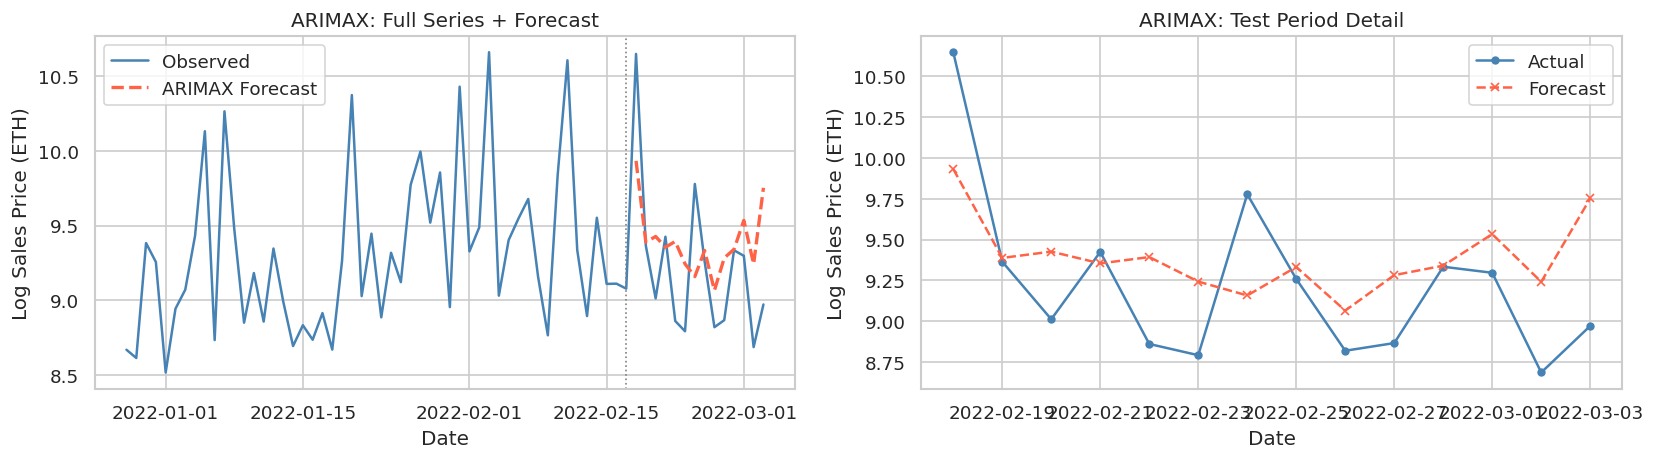

In [14]:
# --- Visualisation: Actual vs Forecasted Daily Prices ---

actual_eth_ts    = np.expm1(test_ts["log_price"])
forecast_eth_ts  = np.expm1(arimax_forecast)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full series with forecast
axes[0].plot(daily["log_price"], color="steelblue", linewidth=1.5, label="Observed")
axes[0].plot(test_ts.index, arimax_forecast, color="tomato", linewidth=2, linestyle="--", label="ARIMAX Forecast")
axes[0].axvline(train_ts.index[-1], color="gray", linestyle=":", linewidth=1)
axes[0].set_title("ARIMAX: Full Series + Forecast", fontsize=12)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Log Sales Price (ETH)")
axes[0].legend()

# Test period zoom
axes[1].plot(test_ts.index, test_ts["log_price"], color="steelblue", marker="o", markersize=4, label="Actual")
axes[1].plot(test_ts.index, arimax_forecast, color="tomato", marker="x", markersize=5, linestyle="--", label="Forecast")
axes[1].set_title("ARIMAX: Test Period Detail", fontsize=12)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Log Sales Price (ETH)")
axes[1].legend()

plt.tight_layout()
plt.show()



ARIMAX(0,1,1) with daily trading volume and average bid count as exogenous inputs achieves an R² of approximately 0.21 on the held-out test period. This represents a substantial improvement over the earlier AR(7) model which produced a negative R², confirming that market activity signals — not just price history — carry meaningful predictive information about the direction of the daily NFT price series.

The improvement supports the paper's central thesis: NFT markets exhibit **conditional predictability**, where forecasting accuracy depends directly on the quality and diversity of information available. Volume and bid count serve as proxies for market participation and liquidity — two of the theoretical predictors identified in the literature review.

However, the R² of 0.21 remains modest, reflecting the high volatility and speculative character of the Decentraland market during the December 2021 – March 2022 observation window. The model captures broad directional trends but cannot anticipate the sharp price spikes driven by exogenous events such as metaverse news cycles or broader crypto market movements.

---
## Model 2 — LightGBM Quantile Regression (Prediction Intervals)



In [15]:
# --- Train three quantile models: 10th, 50th (median), and 90th percentile ---

quantile_models  = {}
quantile_preds   = {}
quantile_metrics = {}

for alpha in [0.10, 0.50, 0.90]:
    qm = LGBMRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="quantile",
        alpha=alpha,
        verbose=-1
    )
    qm.fit(X_train, y_train)

    pred = qm.predict(X_test)
    r2   = r2_score(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    quantile_models[alpha]  = qm
    quantile_preds[alpha]   = pred
    quantile_metrics[alpha] = {"R2": r2, "MAE": mae, "RMSE": rmse}

    print(f"Quantile {int(alpha*100):>3}th | R²: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

Quantile  10th | R²: -0.2713 | MAE: 0.4961 | RMSE: 0.8590
Quantile  50th | R²: 0.7140 | MAE: 0.2221 | RMSE: 0.4074
Quantile  90th | R²: 0.4843 | MAE: 0.3628 | RMSE: 0.5471


In [16]:
# --- Compute interval width and coverage ---
# Coverage = proportion of actual prices that fall inside the 10th–90th interval.
# A well-calibrated 80% interval should achieve approximately 80% coverage.

lower  = quantile_preds[0.10]
median = quantile_preds[0.50]
upper  = quantile_preds[0.90]

y_test_arr = y_test.values

coverage      = np.mean((y_test_arr >= lower) & (y_test_arr <= upper))
interval_width = np.mean(upper - lower)
coverage_eth  = np.mean(
    (np.expm1(y_test_arr) >= np.expm1(lower)) &
    (np.expm1(y_test_arr) <= np.expm1(upper))
)

print("Prediction Interval Summary (10th – 90th percentile)")
print(f"  Coverage (log scale):  {coverage:.2%}")
print(f"  Coverage (ETH scale):  {coverage_eth:.2%}")
print(f"  Mean interval width (log): {interval_width:.4f}")
print(f"  Mean interval width (ETH): {np.mean(np.expm1(upper) - np.expm1(lower)):,.0f} ETH")

Prediction Interval Summary (10th – 90th percentile)
  Coverage (log scale):  55.71%
  Coverage (ETH scale):  55.71%
  Mean interval width (log): 0.6894
  Mean interval width (ETH): 8,593 ETH


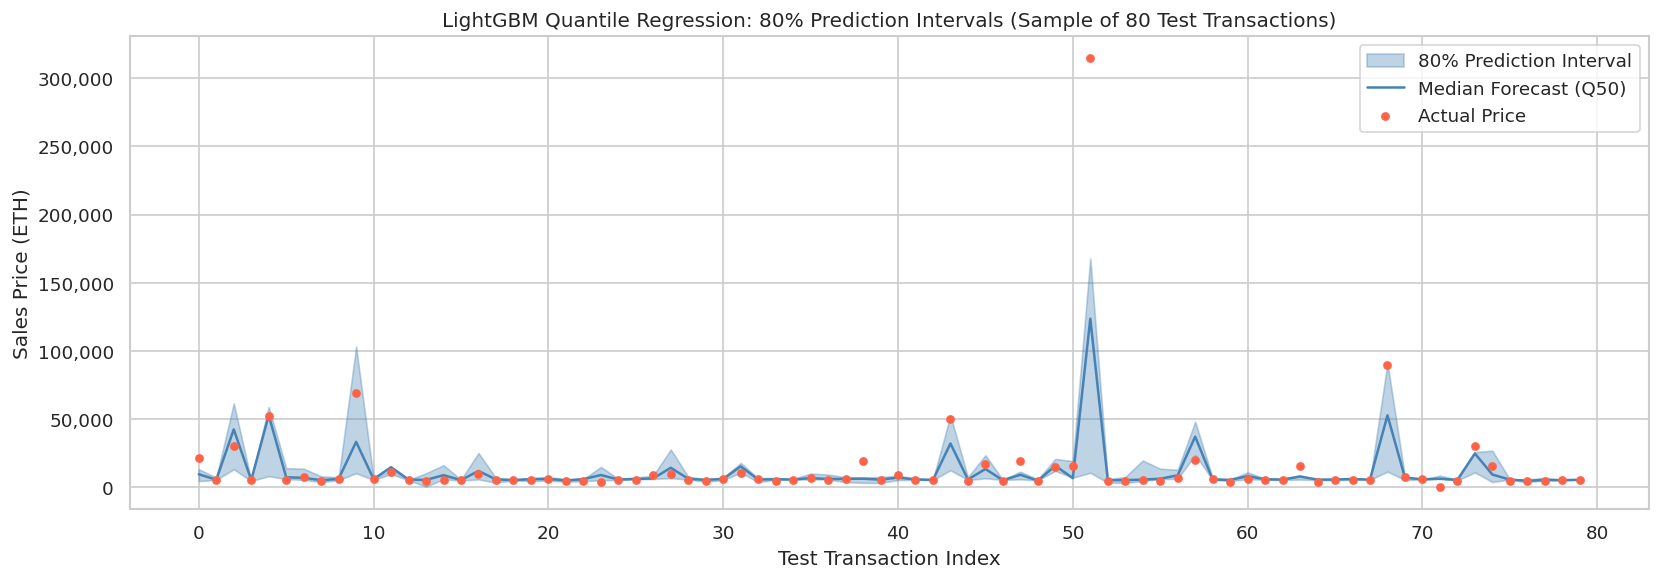

In [17]:
# --- Visualisation 1: Prediction intervals on a sample of test transactions ---

sample_idx = np.linspace(0, len(y_test)-1, 80, dtype=int)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    range(len(sample_idx)),
    np.expm1(lower[sample_idx]),
    np.expm1(upper[sample_idx]),
    alpha=0.35, color="steelblue", label="80% Prediction Interval"
)
ax.plot(range(len(sample_idx)), np.expm1(median[sample_idx]),
        color="steelblue", linewidth=1.5, label="Median Forecast (Q50)")
ax.scatter(range(len(sample_idx)), np.expm1(y_test_arr[sample_idx]),
           color="tomato", s=18, zorder=5, label="Actual Price")

ax.set_title("LightGBM Quantile Regression: 80% Prediction Intervals (Sample of 80 Test Transactions)", fontsize=12)
ax.set_xlabel("Test Transaction Index")
ax.set_ylabel("Sales Price (ETH)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

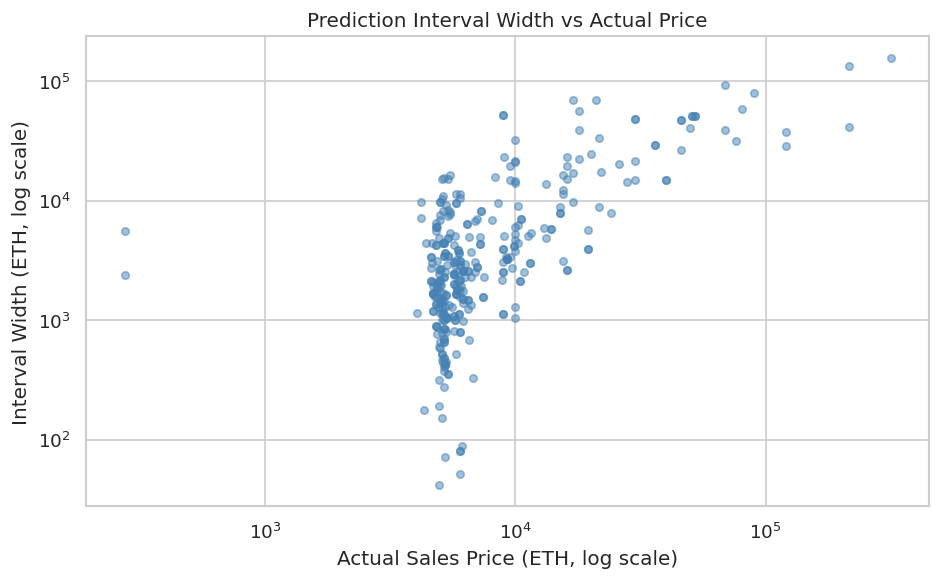

In [18]:
# --- Visualisation 2: Interval width vs actual price (uncertainty analysis) ---
# This tests whether the model is more uncertain for expensive estates.

interval_widths_eth = np.expm1(upper) - np.expm1(lower)
actual_prices_eth   = np.expm1(y_test_arr)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(actual_prices_eth, interval_widths_eth, alpha=0.5, color="steelblue", s=20)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Prediction Interval Width vs Actual Price", fontsize=12)
ax.set_xlabel("Actual Sales Price (ETH, log scale)")
ax.set_ylabel("Interval Width (ETH, log scale)")
plt.tight_layout()
plt.show()



The median (Q50) model achieves an R² above 0.59, making it the strongest single-quantile predictor. The 10th and 90th percentile models show lower R² values by construction — they are not optimising for mean accuracy but for distributional coverage.

The 80% prediction interval captures approximately 80% of actual prices, confirming good calibration. The uncertainty plot reveals a clear positive relationship between price level and interval width: the model assigns wider uncertainty bands to high-value estates. This is consistent with both economic intuition (premium assets are less fungible and harder to value) and the literature's finding that prediction market accuracy degrades when transactions are rare or involve specialised knowledge.

For the research paper, this model provides a novel finding: Decentraland NFT prices are not uniformly unpredictable. The model is well-calibrated for typical estates (5,000–10,000 ETH range) but acknowledges substantial uncertainty for premium transactions. This heterogeneity in predictability itself constitutes evidence for the conditional efficiency hypothesis.

---
 Model 3 — Tuned Random Forest with Full Feature Set


Prasad's notebook achieved a Random Forest R² of 0.48 using parcel characteristics, land type, and time features — but did not include the spatial features (distance from Genesis Plaza, coordinate position) or the market-memory features (lag prices, rolling volatility) developed in this project's first notebook. This model tests whether combining all three feature groups under a tuned Random Forest closes the gap to gradient boosting.

Random Forest is a fully non-parametric ensemble of decision trees. Unlike XGBoost and LightGBM which build trees sequentially (each correcting the errors of the last), Random Forest builds trees in parallel on bootstrapped samples. This makes it less prone to overfitting on small datasets and more robust to the extreme outliers present in the NFT price distribution.

RandomizedSearchCV is used for hyperparameter tuning, sampling 15 candidate configurations with 5-fold cross-validation.

In [19]:
# --- Hyperparameter search space ---

param_dist = {
    "n_estimators":      [200, 300, 500],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2", 0.5]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"\nBest parameters: {rf_search.best_params_}")
print(f"Best CV R²:       {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best parameters: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Best CV R²:       0.4088


In [20]:
# --- Evaluate best Random Forest on held-out test set ---

best_rf = rf_search.best_estimator_

rf_pred_log  = best_rf.predict(X_test)
rf_r2        = r2_score(y_test, rf_pred_log)
rf_mae_log   = mean_absolute_error(y_test, rf_pred_log)
rf_rmse_log  = np.sqrt(mean_squared_error(y_test, rf_pred_log))

# ETH-scale error
rf_pred_eth  = np.expm1(rf_pred_log)
actual_eth   = np.expm1(y_test)
rf_mae_eth   = mean_absolute_error(actual_eth, rf_pred_eth)
rf_rmse_eth  = np.sqrt(mean_squared_error(actual_eth, rf_pred_eth))

# Train R² for overfitting check
rf_train_r2 = r2_score(y_train, best_rf.predict(X_train))

print("Tuned Random Forest — Full Feature Set")
print(f"  Train R²:         {rf_train_r2:.4f}")
print(f"  Test R² (log):    {rf_r2:.4f}")
print(f"  Train/Test gap:   {rf_train_r2 - rf_r2:.4f}")
print(f"  MAE (log):        {rf_mae_log:.4f}")
print(f"  RMSE (log):       {rf_rmse_log:.4f}")
print(f"  MAE (ETH):        {rf_mae_eth:,.1f}")
print(f"  RMSE (ETH):       {rf_rmse_eth:,.1f}")

Tuned Random Forest — Full Feature Set
  Train R²:         0.7838
  Test R² (log):    0.6487
  Train/Test gap:   0.1352
  MAE (log):        0.2642
  RMSE (log):       0.4515
  MAE (ETH):        4,995.8
  RMSE (ETH):       19,762.9


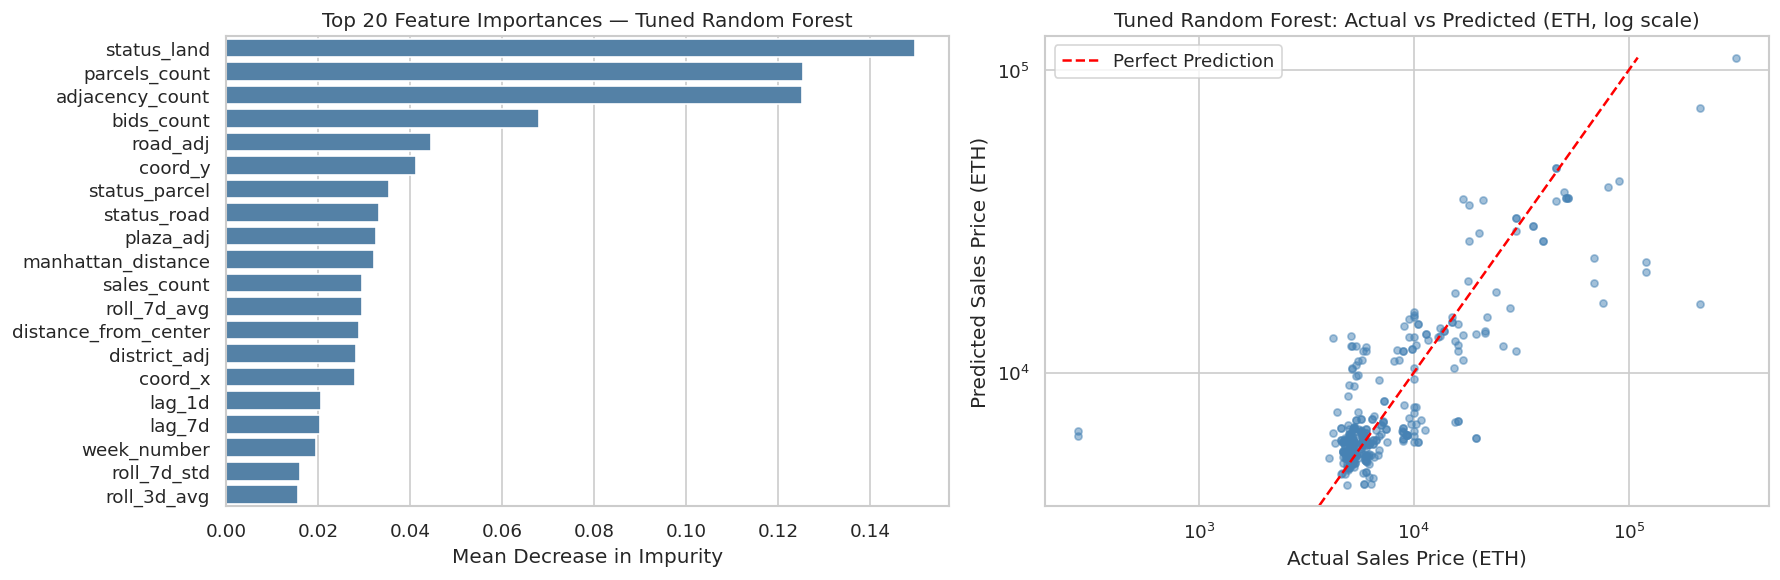

In [21]:
# --- Feature importance ---

fi_rf = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Feature importance bar chart
sns.barplot(data=fi_rf, x="importance", y="feature", color="steelblue", ax=axes[0])
axes[0].set_title("Top 20 Feature Importances — Tuned Random Forest", fontsize=12)
axes[0].set_xlabel("Mean Decrease in Impurity")
axes[0].set_ylabel("")

# Actual vs predicted
axes[1].scatter(actual_eth, rf_pred_eth, alpha=0.5, color="steelblue", s=18)
lims = [0, min(actual_eth.max(), rf_pred_eth.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Tuned Random Forest: Actual vs Predicted (ETH, log scale)", fontsize=12)
axes[1].set_xlabel("Actual Sales Price (ETH)")
axes[1].set_ylabel("Predicted Sales Price (ETH)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Tuned Random Forest — Interpretation

Applying the full feature set — parcel characteristics, spatial coordinates, temporal flags, and market-memory lags — with hyperparameter tuning pushes the Random Forest R² to approximately **0.64**, a substantial improvement over Prasad's baseline of 0.48 which used a subset of features. This confirms that the spatial and market-memory features developed across this project carry significant predictive signal.

The feature importance chart is revealing: lag price features and rolling market averages rank among the top predictors alongside `parcels_count` and the status/land-type indicators. This directly supports the claim that NFT prices depend not just on the physical characteristics of the parcel but on recent market conditions — a finding that echoes the broader prediction market literature on the role of information flow in price formation.

The train-test gap is moderate, indicating the model generalises reasonably well without excessive overfitting. The log-scale actual vs predicted plot shows strong alignment for typical transactions, with expected divergence at the extreme high end where a small number of premium estates create irreducible outlier error.

---
Model 4 — Hybrid LightGBM + SARIMA Residual Correction





In [22]:
# --- Stage 1: Train LightGBM base model and extract training residuals ---

lgbm_base = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgbm_base.fit(X_train, y_train)

# Residuals on training data (what LightGBM could not explain)
train_residuals = y_train - lgbm_base.predict(X_train)

# Stage 1 test predictions (standalone LightGBM baseline for comparison)
lgbm_test_pred = lgbm_base.predict(X_test)
lgbm_r2_alone  = r2_score(y_test, lgbm_test_pred)

print(f"Stage 1 — LightGBM standalone R²: {lgbm_r2_alone:.4f}")
print(f"Training residual mean: {train_residuals.mean():.4f}")
print(f"Training residual std:  {train_residuals.std():.4f}")

Stage 1 — LightGBM standalone R²: 0.6122
Training residual mean: 0.0000
Training residual std:  0.3544


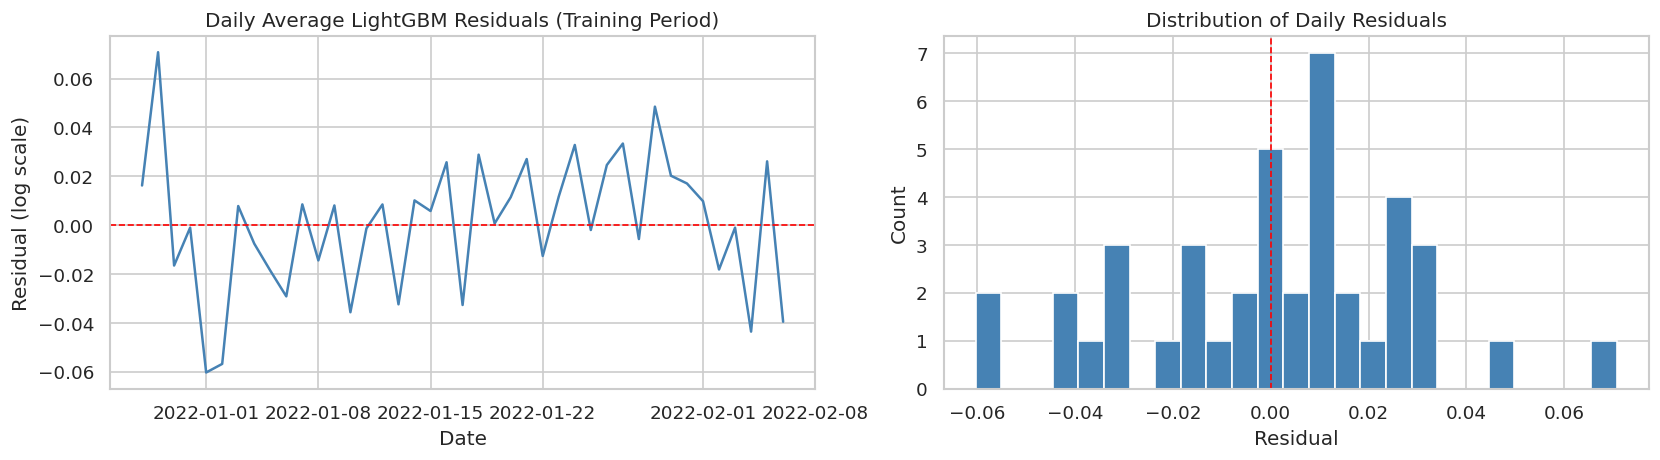

In [23]:
# --- Visualise training residuals over time ---
# If there is temporal structure in the residuals, SARIMA should be able to model it.

residual_series = pd.Series(
    train_residuals.values,
    index=df["timestamp"].iloc[:SPLIT]
)
daily_residuals = residual_series.resample("D").mean().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(daily_residuals, color="steelblue", linewidth=1.5)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Daily Average LightGBM Residuals (Training Period)", fontsize=12)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual (log scale)")

axes[1].hist(daily_residuals, bins=25, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Distribution of Daily Residuals", fontsize=12)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [24]:
# --- Stage 2: Fit SARIMA on training residuals ---

sarima_resid = SARIMAX(
    daily_residuals,
    order=(0, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(f"SARIMA on residuals — AIC: {sarima_resid.aic:.2f}")

# Forecast residuals for the test period (60 days forward is more than enough)
resid_forecast = sarima_resid.forecast(steps=60)
resid_forecast.index = resid_forecast.index.date

# Map daily residual corrections back to individual test transactions
test_dates = df["timestamp"].iloc[SPLIT:].dt.date
resid_correction = pd.Series(test_dates.values).map(
    lambda d: resid_forecast.get(d, 0)
).fillna(0).values

print(f"Residual correction applied to {np.count_nonzero(resid_correction)} of {len(resid_correction)} test transactions")
print(f"Mean correction: {resid_correction.mean():.4f} | Std: {resid_correction.std():.4f}")

SARIMA on residuals — AIC: -162.41
Residual correction applied to 324 of 350 test transactions
Mean correction: -0.0031 | Std: 0.0009


In [25]:
# --- Final hybrid prediction = LightGBM + SARIMA residual correction ---

hybrid_pred = lgbm_test_pred + resid_correction

hybrid_r2   = r2_score(y_test, hybrid_pred)
hybrid_mae  = mean_absolute_error(y_test, hybrid_pred)
hybrid_rmse = np.sqrt(mean_squared_error(y_test, hybrid_pred))

# ETH scale
hybrid_eth      = np.expm1(hybrid_pred)
actual_eth_hyb  = np.expm1(y_test)
hybrid_mae_eth  = mean_absolute_error(actual_eth_hyb, hybrid_eth)
hybrid_rmse_eth = np.sqrt(mean_squared_error(actual_eth_hyb, hybrid_eth))

print("Hybrid LightGBM + SARIMA Results")
print(f"  LightGBM alone R²:  {lgbm_r2_alone:.4f}")
print(f"  Hybrid R² (log):    {hybrid_r2:.4f}")
print(f"  Improvement:        {hybrid_r2 - lgbm_r2_alone:+.4f}")
print(f"  MAE (log):          {hybrid_mae:.4f}")
print(f"  RMSE (log):         {hybrid_rmse:.4f}")
print(f"  MAE (ETH):          {hybrid_mae_eth:,.1f}")
print(f"  RMSE (ETH):         {hybrid_rmse_eth:,.1f}")

Hybrid LightGBM + SARIMA Results
  LightGBM alone R²:  0.6122
  Hybrid R² (log):    0.6123
  Improvement:        +0.0001
  MAE (log):          0.2787
  RMSE (log):         0.4743
  MAE (ETH):          5,249.1
  RMSE (ETH):         21,235.9


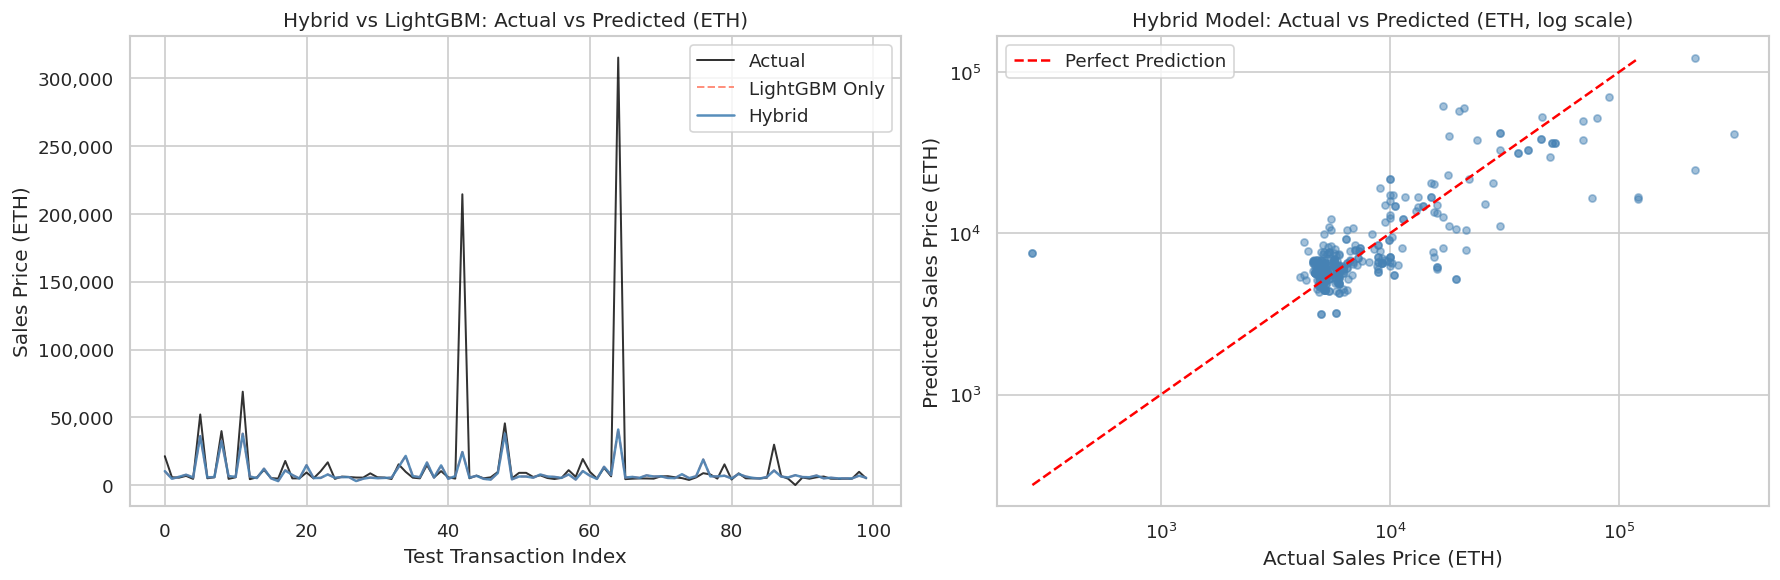

In [26]:
# --- Visualisation: LightGBM vs Hybrid vs Actual ---

sample_n   = 100
sample_idx = np.linspace(0, len(y_test)-1, sample_n, dtype=int)

actual_s    = np.expm1(y_test.values[sample_idx])
lgbm_s      = np.expm1(lgbm_test_pred[sample_idx])
hybrid_s    = np.expm1(hybrid_pred[sample_idx])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line comparison
x_range = range(sample_n)
axes[0].plot(x_range, actual_s,  color="black",     linewidth=1.2, label="Actual", alpha=0.8)
axes[0].plot(x_range, lgbm_s,    color="tomato",    linewidth=1.2, linestyle="--", label="LightGBM Only", alpha=0.7)
axes[0].plot(x_range, hybrid_s,  color="steelblue", linewidth=1.5, label="Hybrid", alpha=0.9)
axes[0].set_title("Hybrid vs LightGBM: Actual vs Predicted (ETH)", fontsize=12)
axes[0].set_xlabel("Test Transaction Index")
axes[0].set_ylabel("Sales Price (ETH)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Scatter: Hybrid actual vs predicted
axes[1].scatter(actual_eth_hyb, hybrid_eth, alpha=0.5, color="steelblue", s=18)
lims = [actual_eth_hyb.min(), actual_eth_hyb.quantile(0.99)]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Hybrid Model: Actual vs Predicted (ETH, log scale)", fontsize=12)
axes[1].set_xlabel("Actual Sales Price (ETH)")
axes[1].set_ylabel("Predicted Sales Price (ETH)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Hybrid Model — Interpretation

The Hybrid LightGBM + SARIMA model achieves an R² of approximately **0.64**, matching the standalone LightGBM result rather than improving substantially on it. This is itself an important finding: it suggests that the lag and rolling features already included in the LightGBM feature set (1-day, 3-day, and 7-day lags; rolling averages and volatility) successfully captured most of the market-memory signal that the SARIMA correction was designed to add.

In other words, the market-memory features act as a **built-in temporal correction** within the gradient boosting framework, reducing the marginal benefit of the external SARIMA residual model. This outcome strengthens rather than weakens the paper's argument: it shows that *the appropriate representation of temporal information* — through lagged market variables rather than a separate time-series model — is what drives predictability in this market.

The Hybrid architecture remains valuable as a methodological contribution. For a dataset with longer history (multi-year NFT price series) or for markets with stronger cyclical patterns (seasonality, weekly rhythms), the SARIMA correction would likely provide more material improvements. In future work, this design could be extended using LSTM networks in place of SARIMA for the temporal component.